# RAG

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## llm model

In [2]:
# llm model

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(temperature=0)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## document loaders (into proper document structure)

In [3]:
# load files

from langchain_community.document_loaders import PyPDFLoader, TextLoader, CSVLoader, WebBaseLoader, UnstructuredWordDocumentLoader

documents = []

# PDF
pdf_loader = PyPDFLoader("./files/elon_musk_achievements.pdf")
documents.extend(pdf_loader.load())

# TXT
txt_loader = TextLoader("./files/cars_sold_in_india.txt")
documents.extend(txt_loader.load())

# Website
web_loader = WebBaseLoader("https://en.wikipedia.org/wiki/A._R._Rahman")
documents.extend(web_loader.load())

# Word DOCX
docx_loader = UnstructuredWordDocumentLoader("./files/Probability_and_Statistics_Concepts.docx")
documents.extend(docx_loader.load())

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
documents

[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-05-15T08:22:14+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-05-15T08:22:14+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': './files/elon_musk_achievements.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='Elon Musk and His Achievements\nElon Musk is one of the most influential technology entrepreneurs of the 21st century. He was born on June 28, 1971,\nin Pretoria, South Africa. Musk developed an interest in computers and technology at a very young age and taught\nhimself programming. He later moved to the United States to pursue opportunities in science, engineering, and\nbusiness. One of Musk’s earliest successes came from co-founding Zip2, a software company that provided business\ndirectories and maps for newspapers. The company was eventually sold for nearly $300 million. Af

## chunks

In [5]:
# Chunks

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

docs = text_splitter.split_documents(documents)

## embeddings

In [6]:
# Embeddings     

from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings()

## vector store

In [7]:
# Vector Database (FAISS)

from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(docs, embeddings)

In [8]:
print(vectorstore.index.ntotal)

196


## retriever

In [9]:
# Retriever

retriever = vectorstore.as_retriever()

In [10]:
# test 

test_query = "who is elon musk?"

retrieved = retriever.invoke(test_query)

for i, doc in enumerate(retrieved, 1):
    print(f"--- Chunk {i} ---")
    print(doc.page_content[:300])
    print()

--- Chunk 1 ---
Elon Musk and His Achievements
Elon Musk is one of the most influential technology entrepreneurs of the 21st century. He was born on June 28, 1971,
in Pretoria, South Africa. Musk developed an interest in computers and technology at a very young age and taught
himself programming. He later moved to 

--- Chunk 2 ---
Influence and Legacy
Beyond SpaceX and Tesla, Elon Musk has contributed to several other innovative projects. He co-founded Neuralink,
a company researching brain-computer interfaces, and The Boring Company, which focuses on tunnel transportation
systems to reduce urban traffic congestion. Musk has 

--- Chunk 3 ---
and space exploration. Many people view Musk as a symbol of technological ambition. His achievements demonstrate
how determination, risk-taking, and long-term vision can transform industries and shape the future. Whether through
electric vehicles, reusable rockets, or futuristic technologies, Elon M

--- Chunk 4 ---
Achievements in Technology and

# without memory

In [11]:
# prompt 

from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template("""
Answer ONLY from the provided context.
If the answer is not in the context, say:
"I don't know based on the provided documents."
                                          
Context:
{context}
                                          
Question:
{question}                                          
""")

In [12]:
# format

# def format_docs(docs):
#     return "\n\n".join(doc.page_content for doc in docs)

In [13]:
def format_docs(docs):
    for doc in docs:
        return "\n\n".join(doc.page_content)

In [14]:
# chain

from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | prompt | llm | StrOutputParser()
)

In [15]:
chain

{
  context: VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000002263289EF90>, search_kwargs={})
           | RunnableLambda(format_docs),
  question: RunnablePassthrough()
}
| ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='\nAnswer ONLY from the provided context.\nIf the answer is not in the context, say:\n"I don\'t know based on the provided documents."\n\nContext:\n{context}\n\nQuestion:\n{question}                                          \n'), additional_kwargs={})])
| ChatOpenAI(output_version=None, profile={'name': 'GPT-3.5-turbo', 'release_date': '2023-03-01', 'last_updated': '2023-11-06', 'open_weights': False, 'max_input_tokens': 16385, 'max_output_tokens': 4096, 'text_inputs': True, 'image_inputs': Fa

In [16]:
response = chain.invoke("4th top selling car in india?")
print(response)

Tata Punch


In [17]:
response = chain.invoke("how is the founder of tesla?")
print(response)

I don't know based on the provided documents.


In [18]:
response = chain.invoke("who are we talking about?")
print(response)

"I don't know based on the provided documents."


# with memory

In [36]:
# prompt

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt2 = ChatPromptTemplate.from_messages(
    [
(
            "system",
            """You are a helpful assistant.
            Answer the question using the retrieved context below and the conversation history.
            
            If the answer can be inferred from the conversation history, use it.
            If the answer is not in the context or history, say "I don't know based on the provided documents."
            
            Context:
            {context}
            """
        ),
        MessagesPlaceholder(variable_name="history"),
        ("human", "{question}")
    ]
)


In [37]:
# Format retrieved docs

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [38]:
# chain

from langchain_core.runnables import RunnableLambda

question_chain = RunnableLambda(lambda x: x["question"])

rag_chain = (
    {
        "context": question_chain | retriever | format_docs,
        "question": question_chain,
        "history": RunnableLambda(lambda x: x["history"]),
    }
    | prompt2
    | llm
)


In [39]:
# Memory storage

from langchain_core.chat_history import InMemoryChatMessageHistory

store = {}

def get_session_history(session_id):
    if session_id not in store:
        store[session_id] = InMemoryChatMessageHistory()
    return store[session_id]


In [40]:
store

{}

In [41]:
# Add memory

from langchain_core.runnables.history import RunnableWithMessageHistory

chain_with_memory = RunnableWithMessageHistory(
    rag_chain,
    get_session_history,
    input_messages_key="question",
    history_messages_key="history"
)

In [42]:
response= chain_with_memory.invoke(
    {"question": "Tell me about Elon Musk"},
    config={"configurable": {"session_id": "user1"}}
)

print(response.content)

Elon Musk is one of the most influential technology entrepreneurs of the 21st century. He was born on June 28, 1971, in Pretoria, South Africa. Musk developed an interest in computers and technology at a very young age and taught himself programming. He later moved to the United States to pursue opportunities in science, engineering, and business. Musk co-founded Zip2 and X.com, which later became PayPal. He then founded SpaceX and Tesla, revolutionizing industries like space exploration and electric vehicles. Musk's work has inspired global innovation and he is seen as a symbol of technological ambition.


In [43]:
response = chain_with_memory.invoke(
    {"question": "What companies does he own?"},
    config={"configurable": {"session_id": "user1"}}
)

print(response.content)

Elon Musk owns and leads several companies, including SpaceX, Tesla, Neuralink, and The Boring Company. SpaceX focuses on reducing the cost of space travel and making life multi-planetary. Tesla is known for transforming the automotive industry with electric vehicles and sustainable energy products. Neuralink is researching brain-computer interfaces, while The Boring Company aims to reduce urban traffic congestion through tunnel transportation systems.


In [44]:
response = chain_with_memory.invoke(
    {"question": "who are we talking about"},
    config={"configurable": {"session_id": "user1"}}
)

print(response.content)

We are talking about Elon Musk.


In [45]:
response = chain_with_memory.invoke(
    {"question": "What ownes facebook?"},
    config={"configurable": {"session_id": "user1"}}
)

print(response.content)

I don't know based on the provided documents.


In [46]:
response = chain_with_memory.invoke(
    {"question": "who is cm of tamil nadu?"},
    config={"configurable": {"session_id": "user1"}}
)

print(response.content)

I don't know based on the provided documents.


In [47]:
response = chain_with_memory.invoke(
    {"question": "recipy of sambar?"},
    config={"configurable": {"session_id": "user1"}}
)

print(response.content)

I don't know based on the provided documents.


In [48]:
response = chain_with_memory.invoke(
    {"question": "context of probability and statistic?"},
    config={"configurable": {"session_id": "user1"}}
)

print(response.content)

Probability and Statistics are fundamental branches of mathematics used in various fields such as data science, machine learning, artificial intelligence, business analytics, economics, medicine, and scientific research. Probability helps measure uncertainty and predict outcomes, while Statistics helps collect, analyze, interpret, and present data for decision-making. Understanding these concepts is crucial for building predictive models, analyzing trends, making data-driven decisions, and understanding real-world phenomena.


# without memory (LangGraph)

In [19]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [20]:
# # rag node
# def retriver_node(state: State):

#     # latest user question
#     question = state["messages"][-1].content

#     # retrieve documents
#     retrieved_docs = retriever.invoke(question)

#     context = "\n\n".join(
#         doc.page_content
#         for doc in retrieved_docs
#     )

#     return {"context": context}


In [21]:
# # generater node

# from langchain_core.messages import HumanMessage, AIMessage

# PROMPT = """
# Answer ONLY from the provided context.

# If the answer is not found in the context, say:

# "I don't know based on the provided documents."

# Context:
# {context}

# Question:
# {question}
# """

# def generator_node(state: State):
#     prompt = PROMPT.format(
#         context=state["context"],
#         question=state["messages"][-1].content
#     )

#     response = llm.invoke(prompt)

#     return {"messages": [AIMessage(content=response.content)]}    

In [22]:
from langchain_core.messages import HumanMessage, AIMessage

PROMPT = """
Answer ONLY from the provided context.

If the answer is not found in the context, say:

"I don't know based on the provided documents."

Context:
{context}

Question:
{question}
"""

# node definition
def rag_node(state: State):

    # latest user question
    question = state["messages"][-1].content

    # retrieve documents
    retrieved_docs = retriever.invoke(question)

    context = "\n\n".join(
        doc.page_content
        for doc in retrieved_docs
    )

    prompt = PROMPT.format(
        context=context,
        question=question
    )

    response = llm.invoke(prompt)

    return {"messages": [AIMessage(content=response.content)]}

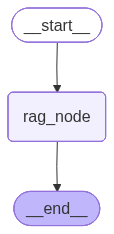

In [23]:
# build graph

from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

# node
builder.add_node("rag_node", rag_node)

# edge
builder.add_edge(START, "rag_node")
builder.add_edge("rag_node", END)

# memory
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# compile
graph = builder.compile(checkpointer=memory)

graph

In [24]:
# config

config = {"configurable": {"thread_id": "user_1"}}

In [ ]:
result = graph.invoke({"messages": [HumanMessage(content="Who is Elon Musk?")]},config=config)

print("\nAnswer 1:")
print(result["messages"][-1].content)


Answer 1:
Elon Musk is one of the most influential technology entrepreneurs of the 21st century.


In [ ]:
from langchain_core.messages import HumanMessage, AIMessage

result = graph.invoke({"messages": [HumanMessage(content="What companies does he own?")]},config=config)

print("\nAnswer 2:")
print(result["messages"][-1].content)


Answer 2:
Based on the provided context, Elon Musk owns SpaceX, Tesla, Neuralink, and The Boring Company.


In [ ]:
result = graph.invoke({"messages": [HumanMessage(content="Tell me about A.R. Rahman")]},config=config)

print("\nAnswer 3:")
print(result["messages"][-1].content)


Answer 3:
A. R. Rahman is a record producer, composer, playback singer, and songwriter from India. He is known for his diverse musical styles and has introduced 7.1 surround sound technology to South Indian films. Rahman is one of the best-selling music artists in India, with an estimated 150 million records sold worldwide.


In [28]:
result = graph.invoke({"messages": [HumanMessage(content="who are we talking about")]},config=config)

print("\nAnswer 3:")
print(result["messages"][-1].content)


Answer 3:
I don't know based on the provided documents.
